In [1]:
# This R environment comes with many helpful analytics packages installed
# It is defined by the kaggle/rstats Docker image: https://github.com/kaggle/docker-rstats
# For example, here's a helpful package to load

library(tidyverse) # metapackage of all tidyverse packages

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

list.files(path = "../input")

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.4
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.4.4     ✔ tibble    3.2.1
✔ lubridate 1.9.3     ✔ tidyr     1.3.0
✔ purrr     1.0.2     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


[1] "oecd-revenue-statistics"

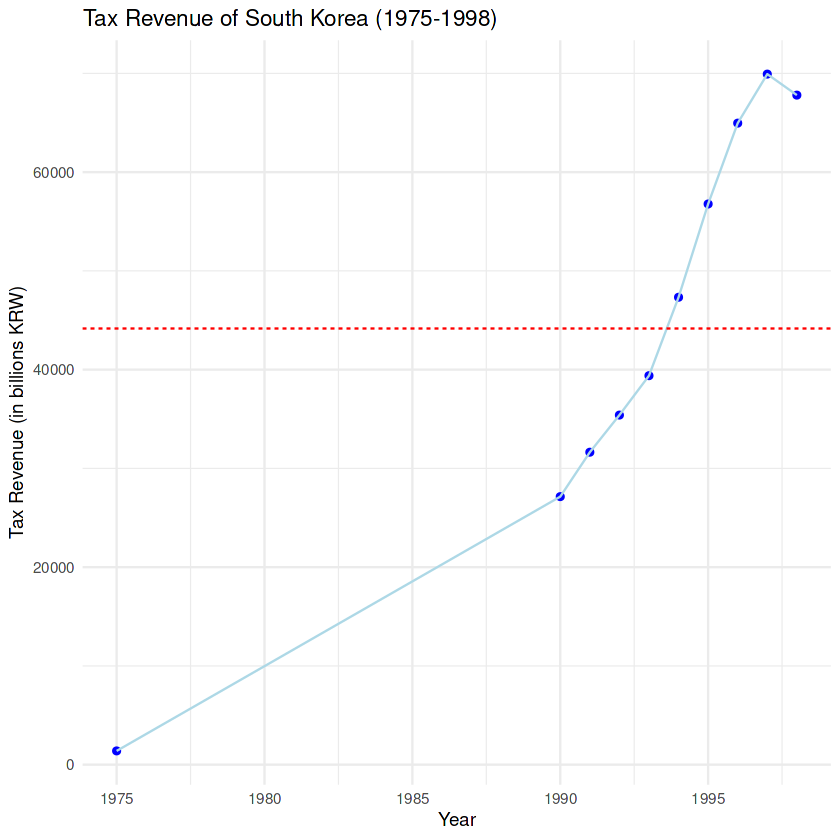

In [2]:
library(ggplot2)

# Dados
years <- c(1975, 1990, 1991, 1992, 1993, 1994, 1995, 1996, 1997, 1998)
tax_revenue <- c(1392.6, 27140.75, 31638.99, 35398.04, 39388.14, 47329.29, 56774.005, 64959.95, 69926.188, 67797.25)

# Criando um dataframe
data <- data.frame(years, tax_revenue)

# Calculando a média
mean_tax_revenue <- mean(tax_revenue)

# Criando o gráfico
ggplot(data, aes(x = years, y = tax_revenue)) +
  geom_point(color = 'blue') +  # Pontos de dispersão
  geom_line(color = 'lightblue') +  # Linha de rastreio de aumento
  geom_hline(yintercept = mean_tax_revenue, color = 'red', linetype = 'dashed') +  # Linha da média
  labs(title = 'Tax Revenue of South Korea (1975-1998)',
       x = 'Year', y = 'Tax Revenue (in billions KRW)') +
  theme_minimal() +
  geom_text(aes(label=ifelse(tax_revenue == mean_tax_revenue, sprintf("Mean: %.2f", mean_tax_revenue), "")),
            vjust=-0.5, color="red")


Warning message:
“Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
ℹ Please use `linewidth` instead.”


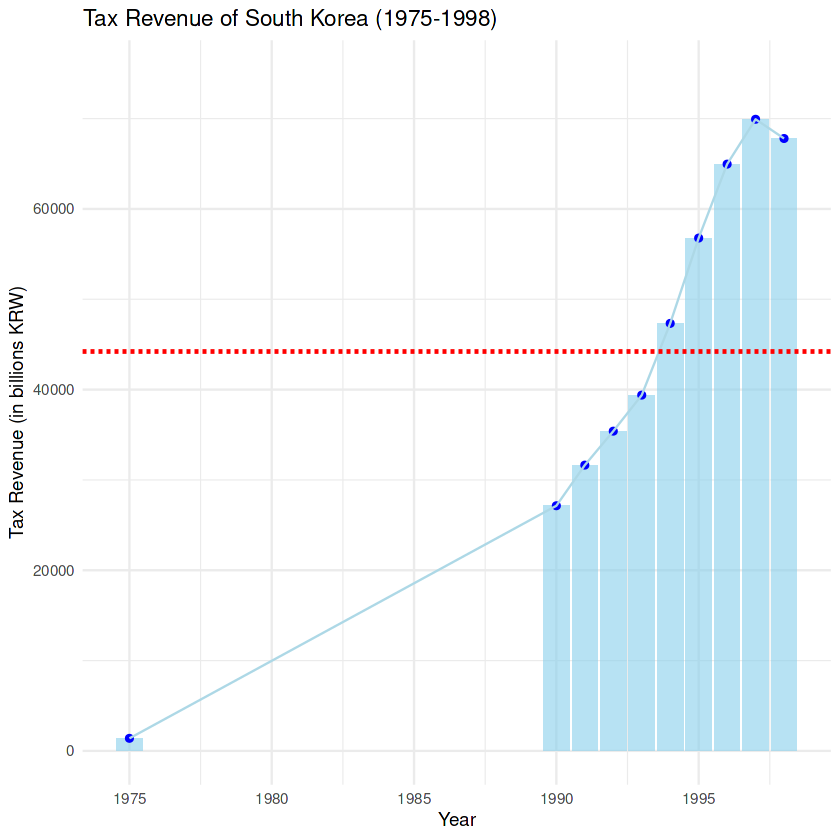

In [3]:
library(ggplot2)
library(dplyr)

# Dados
years <- c(1975, 1990, 1991, 1992, 1993, 1994, 1995, 1996, 1997, 1998)
tax_revenue <- c(1392.6, 27140.75, 31638.99, 35398.04, 39388.14, 47329.29, 56774.005, 64959.95, 69926.188, 67797.25)

# Criando um dataframe
data <- data.frame(years, tax_revenue)

# Calculando a média
mean_tax_revenue <- mean(tax_revenue)

# Criando o gráfico combinado
ggplot(data) +
  geom_bar(aes(x = years, y = tax_revenue), stat = "identity", fill = "skyblue", alpha = 0.6) +
  geom_point(aes(x = years, y = tax_revenue), color = 'blue') +
  geom_line(aes(x = years, y = tax_revenue), color = 'lightblue') +
  geom_hline(yintercept = mean_tax_revenue, color = 'red', linetype = 'dashed', size = 1) +
  labs(title = 'Tax Revenue of South Korea (1975-1998)',
       x = 'Year', y = 'Tax Revenue (in billions KRW)') +
  theme_minimal() +
  geom_text(aes(label=ifelse(tax_revenue == mean_tax_revenue, sprintf("Mean: %.2f", mean_tax_revenue), ""), x = years, y = tax_revenue + 5000),
            vjust=-0.5, color="red", size = 3)


In [4]:
install.packages("fmsb")

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



In [5]:
library(fmsb)

Warning message in plot.window(...):
“"legend" is not a graphical parameter”
Warning message in plot.xy(xy, type, ...):
“"legend" is not a graphical parameter”
Warning message in title(...):
“"legend" is not a graphical parameter”


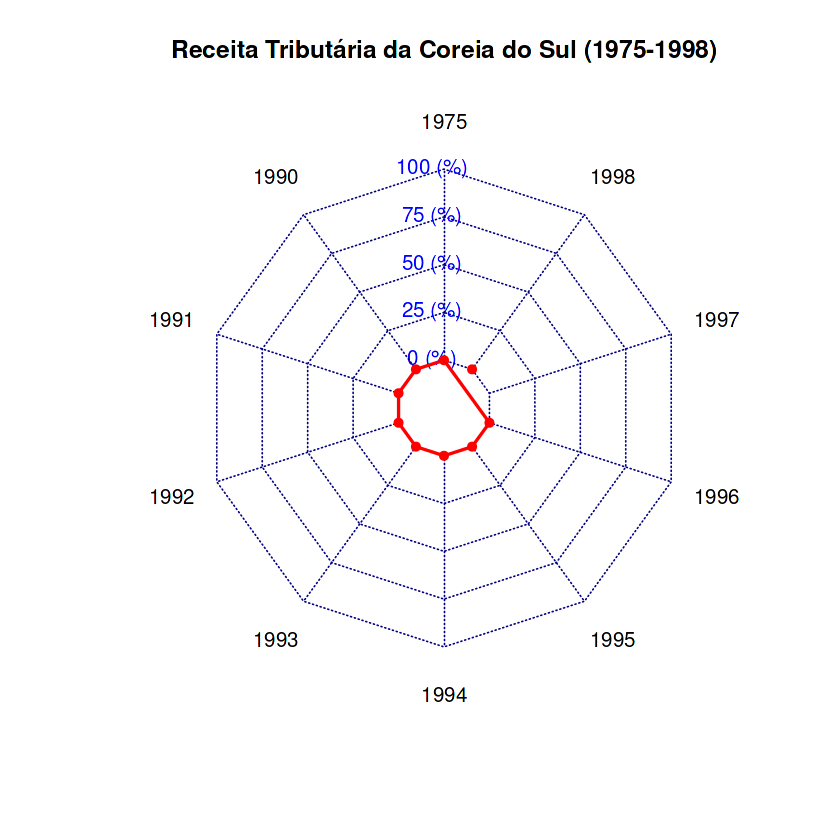

In [6]:
library(fmsb)

# Adaptando os dados para o gráfico de radar
# O gráfico de radar requer um dataframe com a mesma quantidade de colunas para cada ponto do radar

# Primeiro, normalizamos os dados para caber na escala do gráfico de radar
max_revenue <- max(tax_revenue)
normalized_tax_revenue <- tax_revenue / max_revenue * 10  # Escala de 0 a 10, por exemplo

# Criamos um dataframe que se ajuste ao formato exigido pelo fmsb para o gráfico de radar
radar_data <- as.data.frame(rbind(rep(10, length(years)),  # Máximo para definir os limites do gráfico
                                  normalized_tax_revenue))  # Dados normalizados

colnames(radar_data) <- as.character(years)  # Definindo os anos como nomes das colunas

# Adicionando uma linha inicial e final para completar o gráfico
radar_data <- rbind(radar_data, radar_data[2, ])

# Criando o gráfico de radar
radarchart(radar_data, 
           axistype = 1, 
           # Configuração do gráfico
           pcol = c("red", "blue"), plty = 1, plwd = 2,
           # Legenda
           legend = c("Máximo", "Receita Tributária"),
           title = "Receita Tributária da Coreia do Sul (1975-1998)")


Warning message in plot.window(...):
“"legend" is not a graphical parameter”
Warning message in plot.xy(xy, type, ...):
“"legend" is not a graphical parameter”
Warning message in title(...):
“"legend" is not a graphical parameter”


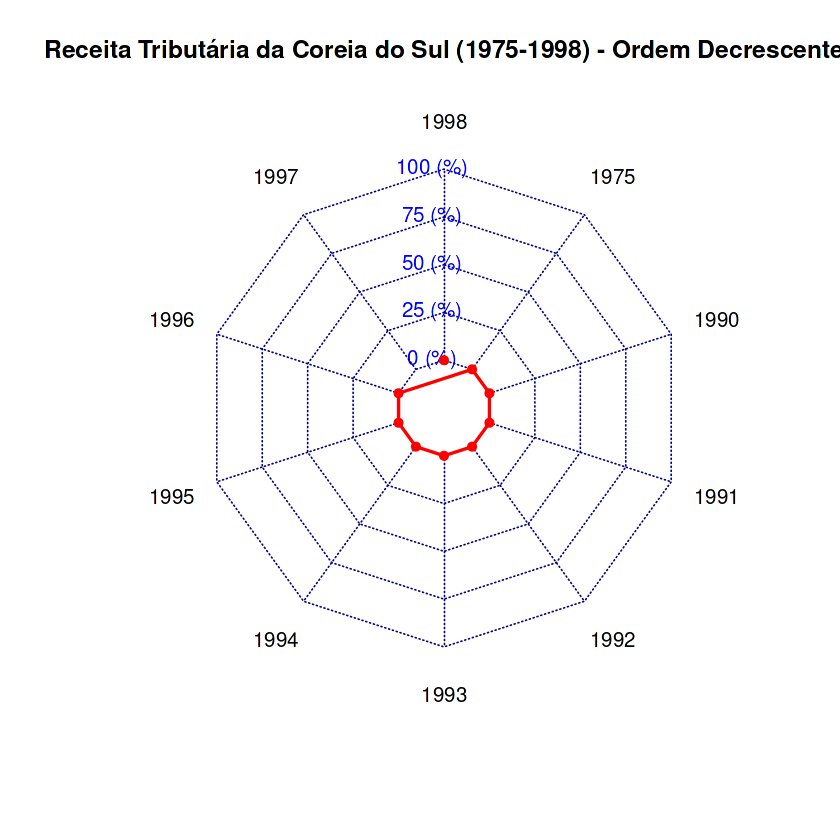

In [7]:
library(fmsb)

# Dados originais
years <- c(1975, 1990, 1991, 1992, 1993, 1994, 1995, 1996, 1997, 1998)
tax_revenue <- c(1392.6, 27140.75, 31638.99, 35398.04, 39388.14, 47329.29, 56774.005, 64959.95, 69926.188, 67797.25)

# Normalizando os dados
max_revenue <- max(tax_revenue)
normalized_tax_revenue <- tax_revenue / max_revenue * 10  # Escala de 0 a 10

# Preparando o dataframe para o gráfico de radar, com os anos em ordem decrescente
years_desc <- sort(years, decreasing = TRUE)
normalized_tax_revenue_desc <- normalized_tax_revenue[order(-years)]

radar_data <- as.data.frame(rbind(rep(10, length(years_desc)),  # Limite máximo para definição dos limites
                                  normalized_tax_revenue_desc))  # Dados normalizados em ordem decrescente

colnames(radar_data) <- as.character(years_desc)  # Definindo os anos como nomes das colunas em ordem decrescente

# Adicionando uma linha inicial e final para completar o gráfico
radar_data <- rbind(radar_data, radar_data[2, ])

# Criando o gráfico de radar com os anos em ordem decrescente
radarchart(radar_data, 
           axistype = 1, 
           pcol = c("red", "blue"), plty = 1, plwd = 2,
           legend = c("Máximo", "Receita Tributária"),
           title = "Receita Tributária da Coreia do Sul (1975-1998) - Ordem Decrescente")
